In [3]:
import os
import yaml
import multiprocessing as mp
import time
import tools21cm as t2c
from tqdm import tqdm
import astropy.units as u
import astropy.constants as cst
import cupy as cp
import numpy as np
import itertools

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"


def filter_baselines(baselines, visibilities, u_freq, v_freq):
    """Filters baselines and corresponding visibilities based on the range of
    frequencies. This is so that the baselines outside the frequency range of
    the fft image are removed.

    Parameters:
    baselines (list): List of baseline coordinates.
    visibilities (list): List of corresponding visibilities.
    u_freq (list): List of u frequencies.
    v_freq (list): List of v frequencies.

    Returns:
    filtered_baselines (ndarray): Numpy array of filtered baseline coordinates.
    filtered_visibilities (ndarray): Numpy array of filtered visibilities.
    """
    filtered_baselines = []
    filtered_visibilities = []

    for baseline, visibility in zip(baselines, visibilities):
        x, y = baseline
        # Check if baseline coordinates are within the range of frequencies
        if (np.min(u_freq) <= x <= np.max(u_freq)) and (
            np.min(v_freq) <= y <= np.max(v_freq)
        ):
            filtered_baselines.append(baseline)
            filtered_visibilities.append(visibility)
    return np.array(filtered_baselines), np.array(filtered_visibilities)



def filter_baselines_cupy(baselines, visibilities, u_freq, v_freq):
    """Filters baselines and corresponding visibilities based on the range of
    frequencies. This is so that the baselines outside the frequency range of
    the fft image are removed.

    Parameters:
    baselines (ndarray): Numpy array of baseline coordinates.
    visibilities (ndarray): Numpy array of corresponding visibilities.
    u_freq (ndarray): Numpy array of u frequencies.
    v_freq (ndarray): Numpy array of v frequencies.

    Returns:
    filtered_baselines (ndarray): CuPy array of filtered baseline coordinates.
    filtered_visibilities (ndarray): CuPy array of filtered visibilities.
    """
    # Convert inputs to CuPy arrays
    baselines_cp = cp.array(baselines)
    visibilities_cp = cp.array(visibilities)
    u_freq_cp = cp.array(u_freq)
    v_freq_cp = cp.array(v_freq)
    
    # Find the min and max frequencies
    u_min, u_max = cp.min(u_freq_cp), cp.max(u_freq_cp)
    v_min, v_max = cp.min(v_freq_cp), cp.max(v_freq_cp)
    
    # Filter baselines based on frequency range
    x = baselines_cp[:, 0]
    y = baselines_cp[:, 1]
    mask = (u_min <= x) & (x <= u_max) & (v_min <= y) & (y <= v_max)
    
    # Apply mask to baselines and visibilities
    filtered_baselines = baselines_cp[mask]
    filtered_visibilities = visibilities_cp[mask]
    
    return filtered_baselines, filtered_visibilities


def read_config(input_path):
    with open(input_path) as stream:
        try:
            config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config


def plot(bare_estimator, ell_mean, var_squared, file_path, img_dpi):
    # Plot the results
    fig, axs = plt.subplots(1, 2, figsize=(17, 5))

    axs[0].errorbar(ell_mean, bare_estimator, np.sqrt(var_squared),
        color="#1f77b4",
        label="Gaussian primary beam",
        elinewidth=0.75,
        capsize=4,
        fmt="o",
        markersize=3)
    axs[0].plot(ell_mean, 5.13 * 1e-4 * (1000 / ell_mean) ** 2.34,
        color="k",
        label="Model",
        alpha=0.75)
    axs[0].set_yscale("log")
    #axs[0].set_ylim(5.13 * 1e-4 * (1000 / ell_mean[-1]) ** 2.34, 5.13 * 1e-4 * (1000 / ell_mean[0]) ** 2.34)
    axs[0].grid()
    axs[0].set_xlabel(r"$\ell$", fontsize=14)
    axs[0].set_ylabel(r"$C_{\ell}$ $[K^2]$", fontsize=14)
    axs[0].legend()

    axs[1].errorbar(ell_mean, ell_mean * (ell_mean + 1) * bare_estimator / (2 * np.pi), ell_mean * (ell_mean + 1) * np.sqrt(var_squared) / (2 * np.pi),
        color="#1f77b4",
        label="Gaussian primary beam",
        elinewidth=0.75,
        capsize=4,
        fmt="o",
        markersize=3)
    axs[1].plot(ell_mean, ell_mean * (ell_mean + 1) * 5.13 * 1e-4 * (1000 / ell_mean) ** 2.34 / (2 * np.pi),
        color="k",
        label="Model",
        alpha=0.75)
    axs[1].set_yscale("log")
    axs[1].set_xscale("log")
    # axs[1].set_ylim(ell_mean[-1] * (ell_mean[-1] + 1) * 5.13 * 1e-4 * (1000 / ell_mean[-1]) ** 2.34 / (2 * np.pi),
    #     ell_mean[0] * (ell_mean[0] + 1) * 5.13 * 1e-4 * (1000 / ell_mean[0]) ** 2.34 / (2 * np.pi))
    # axs[1].set_xlim(1e2, 1e4)
    axs[1].grid()
    axs[1].set_xlabel(r"$\ell$", fontsize=14)
    axs[1].set_ylabel(r"$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$", fontsize=14)
    axs[1].legend()
    # Create the folder if it does not exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    plt.savefig(file_path, dpi=img_dpi)
    # plt.show()


def setup(config, bls, vis):
    # Determine which function to use based on the configuration
    estimator_func_choice = config.get('computation_type')
    if estimator_func_choice == 'cupy':
        bare_estimator_func = bare_estimator_func_cupy
    elif estimator_func_choice == 'noMP':
        bare_estimator_func = bare_estimator_func_v4_noMP
    elif estimator_func_choice == 'MP':
        bare_estimator_func = bare_estimator_func_v4
    else:
        print('Computation type input invalid. Can be \'MP\' for multiprocessing,',
              '\'noMP\' for no multiprocessing, and \'cupy\'.')
        
    
    binning_method = config["binning_method"]
    num_bins = config["num_bins"]
    theta_maj = config["theta_maj"]
    theta_min = config["theta_min"]
    theta_fwhm= np.mean([theta_maj, theta_min])
    precision = config["precision"]

    bare_estimator, ell_mean, var_squared= bare_estimator_func(bls, vis, theta_fwhm, num_bins, binning_method, precision)
    
    return bare_estimator, ell_mean, var_squared


def parse_timesteps(timesteps_config):
    if isinstance(timesteps_config, str):
        start, end = map(int, timesteps_config.split(':'))
        return list(range(start, end))
    elif isinstance(timesteps_config, list):
        return timesteps_config
    else:
        raise ValueError("Invalid format for timesteps. Use a list or a range string (e.g., '50:60').")
        

def _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    """
    The provided arrays should be cupy arrays.
    """
    # Step 1: Calculate the number of elements per bin
    num_elements = len(blmag_sorted)
    elements_per_bin = num_elements // num_bins
    extra_elements = num_elements % num_bins

    # Step 2: Create an array of bin sizes
    bin_sizes = cp.full(num_bins, elements_per_bin)
    bin_sizes[:extra_elements] += 1

    # Step 3: Calculate the cumulative sum of bin sizes
    cumulative_sizes = cp.cumsum(bin_sizes)
    cumulative_sizes_np = cp.asnumpy(cumulative_sizes)  # Convert to NumPy array

    # Step 4: Initialize the bins
    blcoord_bins = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    blmag_bins = cp.split(blmag_sorted, cumulative_sizes_np[:-1])
    vis_bins = cp.split(vis_sorted, cumulative_sizes_np[:-1])

    return blcoord_bins, blmag_bins, vis_bins

def _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    bins = cp.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins) - 1
    
    # Use histogram to count the occurrences of each bin
    hist, _ = cp.histogram(bin_indices, bins=cp.arange(0, num_bins + 1))

    # Calculate the cumulative counts to determine the indices where each bin's values start and end
    cum_counts = cp.cumsum(hist)
    cumulative_sizes_np = cp.asnumpy(cum_counts)  # Convert to NumPy array

    bin_blcoords = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    bin_vis = cp.split(vis_sorted, cumulative_sizes_np[:-1])
    bin_blmags = cp.split(blmag_sorted, cumulative_sizes_np[:-1])

    return bin_blcoords, bin_vis, bin_blmags


def compute_vals_cupy(blcoord, vis, sigma_0, V_0, bin_number):

    bin_len = len(blcoord)
    if bin_len == 0 or bin_len == 1:
        return 0, 0, 0

    # Create a meshgrid for vectorized pairwise operations
    idx_i, idx_j = np.triu_indices(bin_len, k=1)
    idx_i = cp.asarray(idx_i)
    idx_j = cp.asarray(idx_j)

    # Calculate pairwise distances
    delta= blcoord[idx_i] - blcoord[idx_j]
    distance_norm = cp.linalg.norm(delta, axis=1)
    
    combination_len_unfiltered= len(distance_norm)
    
    # Filter pairs where distance is less than or equal to sigma_0
    valid_pairs = distance_norm > sigma_0
    if not cp.any(valid_pairs):
        return 0, 0, 0

    distance_norm = distance_norm[valid_pairs]
    idx_i = idx_i[valid_pairs]
    idx_j = idx_j[valid_pairs]
    
    combination_len_filtered= len(distance_norm)
    #print("Bin", bin_number, ":Theoretical combinations: ", combination_len_unfiltered,
    #     " - When filtered: ", combination_len_filtered)
    
    # Calculate weights
    weight = cp.exp(-(distance_norm**2) / (sigma_0**2))

    # Calculate the visibility product
    visibility_product = vis[idx_i] * cp.conj(vis[idx_j])

    #Calclating the bare estimator
    be_numerator = cp.sum(weight * visibility_product)
    be_denominator = cp.sum(weight * V_0 * cp.exp(-(distance_norm**2) / (sigma_0**2)))

    #Calculating the mean of ell
    l_i = 2 * cp.pi * cp.sqrt(blcoord[idx_i, 0]**2 + blcoord[idx_i, 1]**2)
    exp_weight_distance = weight * cp.exp(-(distance_norm**2) / (sigma_0**2))

    ell_numerator = cp.sum(exp_weight_distance * l_i)
    ell_denominator = cp.sum(exp_weight_distance)

    #Computing arrays needed for the error (variance)
    #Eb_square_mean_numerator = cp.sum((exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34) ** 2)
    #Eb_mean_square_numerator = cp.sum(exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
    Eb_square_mean_numerator = cp.sum((exp_weight_distance * 513 * (1000 / l_i) ** 2.34) ** 2)
    Eb_mean_square_numerator = cp.sum(exp_weight_distance * 513 * (1000 / l_i) ** 2.34)
    Eb_denominator = cp.sum(exp_weight_distance)

    bare_estimator = cp.abs(be_numerator) / be_denominator
    ell_mean = ell_numerator / ell_denominator
    var_squared = (Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator) ** 2)

    # Convert results back to numpy arrays
    bare_estimator = cp.asnumpy(bare_estimator)
    ell_mean = cp.asnumpy(ell_mean)
    var_squared = cp.asnumpy(var_squared)

    return bare_estimator, ell_mean, np.abs(var_squared)


def bare_estimator_func_cupy(baselines, visibilities, theta_fwhm, num_bins, bin_type, precision= 'single'):
    # Set data types based on the precision parameter
    if precision == 'single':
        float_dtype = cp.float32
        complex_dtype = cp.complex64
    elif precision == 'double':
        float_dtype = cp.float64
        complex_dtype = cp.complex128
    else:
        raise ValueError("Unsupported precision type. Use 'single' or 'double'.")
    
    theta_0 = 0.6 * theta_fwhm
    V_0 = np.pi * theta_0**2 / 2
    sigma_0 = 0.76 / theta_fwhm

    start_time = time.time()
    # Step 0: turn arrays into cupy arrays
    baselines= cp.asarray(baselines, dtype= float_dtype)
    visibilities= cp.asarray(visibilities, dtype= complex_dtype)

    # Step 1: Calculate the baseline magnitudes
    bl_mag = cp.linalg.norm(baselines, axis=1)

    # Stack baselines, magnitudes, and visibilities into a single array for sorting
    #combined_array = cp.hstack((baselines[:,0, None], baselines[:,1, None], bl_mag[:, None], visibilities[:, None]))
    combined_array = cp.hstack((baselines[:], bl_mag[:, None], visibilities[:, None]))

    # Sort the combined array based on the magnitudes
    sorted_combined_array = combined_array[cp.argsort(combined_array[:,2])]

    # Split the sorted array back into individual components
    blcoord_sorted = sorted_combined_array[:, 0:2]
    blmag_sorted = sorted_combined_array[:, 2]
    vis_sorted = sorted_combined_array[:, -1]

    #print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = cp.log10(blmag_sorted)
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        blcoord_bins, blmag_bins, vis_bins = _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")

    end_time = time.time()
    #print('Time to sort and bin values: ', end_time-start_time, 's')

    # Verify the bins
    #for i, bin in enumerate(blcoord_bins):
    #    print(f"Bin {i+1}: {len(bin)} elements - Combinations: {int(len(bin)*(len(bin)-1) / 2)}")
    # Print to verify the results
    #print("Total elements after binning: ", cp.sum(cp.array([len(bin) for bin in blmag_bins])))

    bare_estimators = np.empty(num_bins, dtype=float_dtype)
    average_ells = np.empty(num_bins, dtype=float_dtype)
    square_variances = np.empty(num_bins, dtype=float_dtype)

    start_time = time.time()
    for i in range(num_bins):
        bin_number = i + 1
        BE, ell_avg, var_squared= compute_vals_cupy(blcoord_bins[i], vis_bins[i], sigma_0, V_0, bin_number) 

        bare_estimators[i] = BE
        average_ells[i] = ell_avg
        square_variances[i] = var_squared
    end_time = time.time()
    #print('Time to run the bare estimator: ', end_time-start_time, 's')
    
    return bare_estimators, average_ells, square_variances


def compute_vals(bin_values, sigma_0, V_0, bin_number):
    bin_len = len(bin_values)

    if bin_len == 0 or bin_len == 1:
        return 0, 0, 0

    be_numerator = 0
    be_denominator = 0
    ell_numerator = 0
    ell_denominator = 0
    cntr = 0
    Eb_square_mean_numerator = 0
    Eb_mean_square_numerator = 0
    Eb_denominator = 0

    pair_combs = list(itertools.combinations(range(bin_len), 2))
    for i in range(len(pair_combs)):
        distance = bin_values[pair_combs[i][0]][0] - bin_values[pair_combs[i][1]][0]
        distance_norm = np.linalg.norm(distance)

        if distance_norm <= sigma_0:
            continue

        cntr += 1
        weight = np.exp(-(distance_norm**2) / sigma_0**2)
        visibility_product = bin_values[pair_combs[i][0]][2] * np.conj(bin_values[pair_combs[i][1]][2])
        be_numerator += weight * visibility_product
        be_denominator += weight * V_0 * np.exp(-(distance_norm**2) / (sigma_0**2))

        u_i = bin_values[pair_combs[i][0]][0][0]
        v_i = bin_values[pair_combs[i][0]][0][1]
        l_i = 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
        ell_numerator += weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * l_i
        ell_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

        Eb_square_mean_numerator += (weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * 5.13 * 1e-4 * (1000 / l_i) ** 2.34) ** 2
        Eb_mean_square_numerator += (weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
        Eb_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

    if distance_norm <= sigma_0:
        return 0, 0, 0
    
    #print("Bin", bin_number, ":Theoretical combinations: ", len(pair_combs),
    #     " - When filtered: ", cntr)

    bare_estimator = np.abs(be_numerator) / be_denominator
    ell_mean = ell_numerator / ell_denominator
    var_squared = (Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator) ** 2)

    return bare_estimator, ell_mean, np.abs(var_squared)


def _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    bins = np.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values = {i: [] for i in range(1, num_bins + 1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    return bin_values


def _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    # Calculate number of elements per bin
    elements_per_bin = len(blmag_sorted) // num_bins
    remainder = len(blmag_sorted) % num_bins

    bin_values = {}

    # Distribute elements into bins
    start_idx = 0
    for i in range(num_bins):
        end_idx = start_idx + elements_per_bin
        if i < remainder:
            end_idx += 1  # Distribute remainder elements
        bin_values[i + 1] = list(zip(blcoord_sorted[start_idx:end_idx], blmag_sorted[start_idx:end_idx], vis_sorted[start_idx:end_idx],))
        start_idx = end_idx
    return bin_values


def bare_estimator_func_v4(baselines, visibilities, theta_fwhm, num_bins, bin_type):
    theta_0 = 0.6 * theta_fwhm
    V_0 = np.pi * theta_0**2 / 2
    sigma_0 = 0.76 / theta_fwhm
    
    start_time = time.time()
    #Calculating baseline magnitudes and sorting the three arrays according to them
    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)
    
    #print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = np.log10(blmag_sorted)
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
        
    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        bin_values = _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")
        
    end_time = time.time()
    #print('Time to sort and bin values: ', end_time - start_time, 's')
    
    #Verify the bins
    total_elements = 0 # Initialize the total length variable
    for i in range(len(bin_values)):
        bin_len = len(bin_values[i+1])
        total_elements += bin_len
        print(f"Bin {i+1}: {bin_len} elements - Combinations: {int(bin_len*(bin_len-1) / 2)}")
    # Print to verify the results
    #print("Total elements after binning: ", total_elements)
    
    start_time = time.time()
    # create a pool of processes
    pool = mp.Pool(processes=num_bins)
    # map the function to the input data and calculate the results
    results = pool.starmap(
        compute_vals, [(bin_values[key], sigma_0, V_0, key) for key in bin_values.keys()]
    )
    pool.close()
    pool.join()
    end_time = time.time()
    #print('Time to run the bare estimator: ', end_time-start_time, 's')
    
    # Combine the results from the processes
    bare_estimator = []
    ell_mean = []
    var_squared = []
    for result in results:
        bare_estimator.append(result[0])
        ell_mean.append(result[1])
        var_squared.append(result[2])

    np_bare_estimator = np.array(bare_estimator)
    np_ell_mean = np.array(ell_mean)
    np_var_squared = np.array(var_squared)
    
    # remove zero values from the arrays
    #np_bare_estimator = np_bare_estimator[np_bare_estimator != 0]
    #np_ell_mean = np_ell_mean[np_ell_mean != 0]
    #np_var_squared = np_var_squared[np_var_squared != 0]

    return np_bare_estimator, np_ell_mean, np_var_squared


def bare_estimator_func_v4_noMP(baselines, visibilities, theta_fwhm, num_bins, bin_type):
    theta_0 = 0.6 * theta_fwhm
    V_0 = np.pi * theta_0**2 / 2
    sigma_0 = 0.76 / theta_fwhm
    
    start_time = time.time()
    #Calculating baseline magnitudes and sorting the three arrays according to them
    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)
    
    #print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = np.log10(blmag_sorted)
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
        
    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        bin_values = _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")
        
    end_time = time.time()
    #print('Time to sort and bin values: ', end_time - start_time, 's')
    
    #Verify the bins
    total_elements = 0 # Initialize the total length variable
    for i in range(len(bin_values)):
        bin_len = len(bin_values[i+1])
        total_elements += bin_len
        print(f"Bin {i+1}: {bin_len} elements - Combinations: {int(bin_len*(bin_len-1) / 2)}")
    # Print to verify the results
    #print("Total elements after binning: ", total_elements)
    
    start_time = time.time()
    #Running the bare_estimator for every key (bin)
    results= []
    for key in bin_values.keys():
        result= compute_vals(bin_values[key], sigma_0, V_0, key)
        results.append(result)
    end_time = time.time()
    #print('Time to run the bare estimator: ', end_time-start_time, 's')
    
    # Combine the results from the processes
    bare_estimator = []
    ell_mean = []
    var_squared = []
    for result in results:
        bare_estimator.append(result[0])
        ell_mean.append(result[1])
        var_squared.append(result[2])

    np_bare_estimator = np.array(bare_estimator)
    np_ell_mean = np.array(ell_mean)
    np_var_squared = np.array(var_squared)
    
    # remove zero values from the arrays
    #np_bare_estimator = np_bare_estimator[np_bare_estimator != 0]
    #np_ell_mean = np_ell_mean[np_ell_mean != 0]
    #np_var_squared = np_var_squared[np_var_squared != 0]

    return np_bare_estimator, np_ell_mean, np_var_squared

**************************************************
Timestep 0
**************************************************
Timestep 1
**************************************************
Timestep 2
**************************************************
Timestep 3
**************************************************
Timestep 4
**************************************************
Timestep 5
**************************************************
Timestep 6
**************************************************
Timestep 7
**************************************************
Timestep 8
**************************************************
Timestep 9
Time to run the analysis:  10.394 s
Bare estimator values: [2.95403708e+04 3.16125096e+03 8.80461683e+02 7.53972688e+02
 2.71965666e+02 3.49218409e+02 1.10198323e+02 1.58016552e+02
 3.74785374e+01 1.08205893e+02 3.66401913e+01 1.57836863e+01
 1.89465063e+01 8.41604448e+00 5.06209875e+00 1.80228387e+00
 7.20561672e-01 3.24733099e-01 1.08505784e-02 2.89395874e-03]
Ell mean values

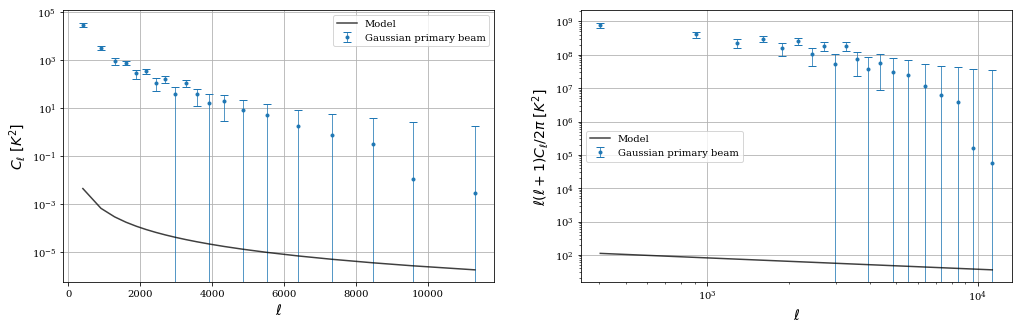

In [4]:
if __name__ == "__main__":
    config = read_config("input/config_SKA_multistep.yaml")
    
    #Setting the timestep list using the parse_timesteps function
    timesteps = parse_timesteps(config["timesteps"])
    
    num_times= config["num_times"]
    theta_maj = config["theta_maj"]
    theta_min = config["theta_min"]
    theta_fwhm = np.mean([theta_maj, theta_min])
    filter_baselines_enabled = config.get("filter_baselines_enabled", True)
    
    num_bins = config["num_bins"]
    all_bare_ests  = np.empty((len(timesteps), num_bins))
    all_ell_means = np.empty((len(timesteps), num_bins))
    all_var_squares = np.empty((len(timesteps), num_bins))

    all_bls= np.load('baselines_all_dTgf_32.npy', mmap_mode='r')
    all_vis= np.load('visibilities_all_dTgf.npy', mmap_mode='r')

    uv_range= config["uv_range"]

    timestep_len = len(all_bls) // num_times
    
    start_time = time.time()
    for count, timestep in enumerate(timesteps):
        print('*'*50)
        print('Timestep', timestep)
        bls= all_bls[timestep * timestep_len : (timestep + 1) * timestep_len]
        vis= all_vis[timestep * timestep_len : (timestep + 1) * timestep_len]
        
        # Decides whether to filter the baselines based on the uv range
        if filter_baselines_enabled:
            bls_filter, vis_filter = filter_baselines_cupy(bls, vis, uv_range, uv_range)
        else:
            bls_filter = bls
            vis_filter = vis
        
        # Filters baselines with 0 visibility
        non_zero_indices = np.where(vis_filter != 0)[0]
        bls_filter = bls_filter[non_zero_indices]
        # np.squeeze because the visibility dimension has to be (len(vis),)
        vis_filter = np.squeeze(vis_filter[non_zero_indices])

        # Initializing the setup and the bare estimator computation
        bare_estimator, ell_mean, var_squared = setup(config, bls_filter, vis_filter)
        
        # Squeeze the arrays to remove single-dimensional entries
        all_bare_ests[count] = np.squeeze(bare_estimator)
        all_ell_means[count] = np.squeeze(ell_mean)
        all_var_squares[count] = np.squeeze(var_squared)
    
    end_time = time.time()
    print("Time to run the analysis: ", round(end_time - start_time, 3), 's')
    
    bare_estimator_avg= np.mean(all_bare_ests, axis=0)
    ell_mean_avg= np.mean(all_ell_means, axis=0)
    var_squared_avg= np.mean(all_var_squares, axis=0)
    
    print("Bare estimator values:", bare_estimator_avg)
    print("Ell mean values:", ell_mean_avg)
    print("Variance squared values:", var_squared_avg)
    
    # Generate filename based on filtering setting
    if filter_baselines_enabled:
        filename_plot = (
            f"PLT_SKA_BE_{timesteps[0]}to{timesteps[-1]}steps_"
            f"uvRngPm{uv_range[-1]}_"
            f"bins{config['num_bins']}_"
            f"{config['precision']}precision_"
            f"{config['binning_method']}.png")
        
        filename_npz= (
            f"NPARR_SKA_BE_{timesteps[0]}to{timesteps[-1]}steps_"
            f"uvRngPm{uv_range[-1]}_"
            f"bins{config['num_bins']}_"
            f"{config['precision']}precision_"
            f"{config['binning_method']}.png")
    else:
        filename_plot = (
            f"PLT_SKA_BE_{timesteps[0]}to{timesteps[-1]}steps_"
            f"nofilter_"
            f"bins{config['num_bins']}_"
            f"{config['precision']}precision_"
            f"{config['binning_method']}.png")
        
        filename_npz =  (
            f"NPARR_SKA_BE_{timesteps[0]}to{timesteps[-1]}steps_"
            f"nofilter_"
            f"bins{config['num_bins']}_"
            f"{config['precision']}precision_"
            f"{config['binning_method']}.png")
    
    print('Npz filename: ', filename_npz)
    
    # Plot the results
    full_file_path_plot = os.path.join(os.path.dirname("output/"), filename_plot)
    plot(bare_estimator_avg, ell_mean_avg, var_squared_avg, file_path=full_file_path_plot, img_dpi=config['img_dpi'])
    
    """
    # Save the arrays as a numpy file
    full_file_path_npz = os.path.join(os.path.dirname("output/"), filename_npz)
    npz_filename = os.path.splitext(full_file_path_npz)[0] + ".npz"
    np.savez(npz_filename, bare_estimator_avg=bare_estimator_avg, ell_mean_avg=ell_mean_avg, var_squared_avg=var_squared_avg)
    """

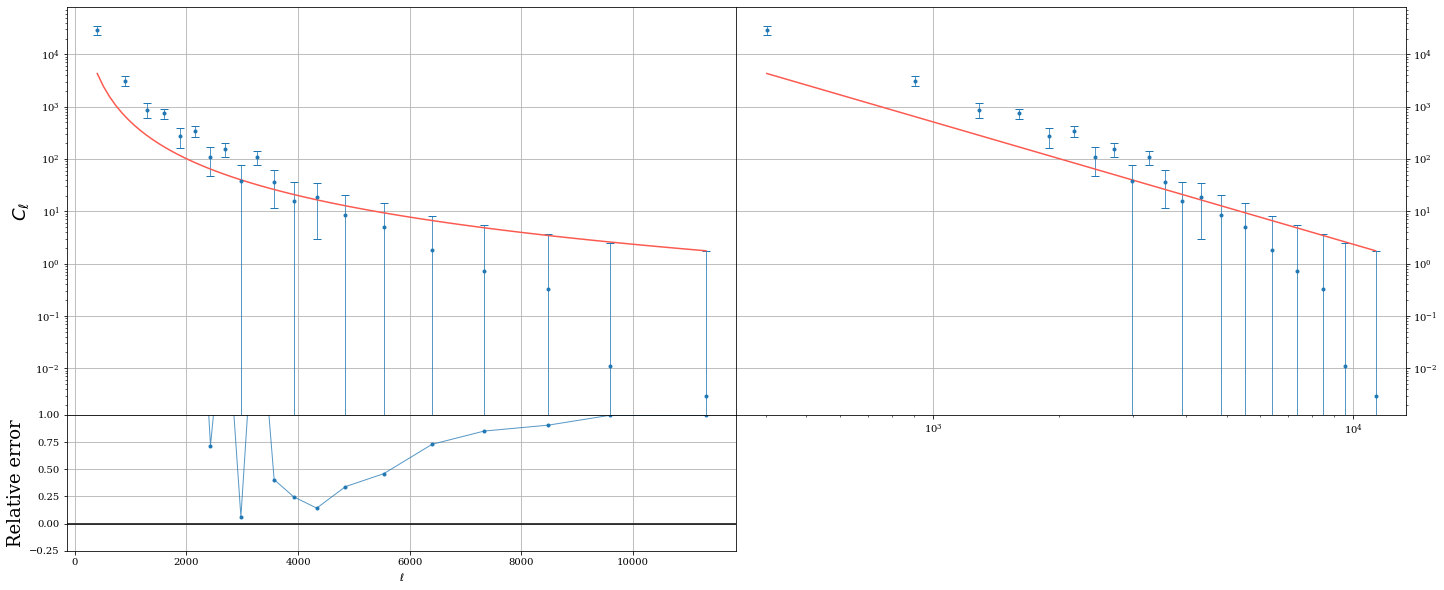

In [5]:
# Create a larger figure with more space
f = plt.figure(figsize=(24, 10))  # Adjust the width and height as needed
gs = f.add_gridspec(2, 2, hspace=0., wspace=0., height_ratios=[3, 1])  # Add a second column
ax1 = f.add_subplot(gs[0, 0])
ax2 = f.add_subplot(gs[1, 0])  # Original plots in the first column
ax3 = f.add_subplot(gs[0, 1])  # New plot in the second column

# Plot the data in the first column
ax1.errorbar(np.squeeze(ell_mean_avg), np.squeeze(bare_estimator_avg), np.sqrt(np.squeeze(var_squared_avg)), 
              color="#1f77b4",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ells_linspace = np.linspace(np.min(ell_mean_avg), np.max(ell_mean_avg), 100)
ax1.plot(ells_linspace, 513 * (1000 / ells_linspace) ** 2.34, color='#FC5A50')
ax1.set_ylabel(r"$C_{\ell}$", fontsize = 18)
ax1.set_yscale('log')
ax1.set_xticklabels([])
ax1.grid()

# Calculate true values and plot relative error in the first column
cylpowerspec_truevals = 513 * (1000 / np.squeeze(ell_mean_avg)) ** 2.34
ax2.plot(np.squeeze(ell_mean_avg), np.abs((np.squeeze(bare_estimator_avg) - cylpowerspec_truevals) / cylpowerspec_truevals), ".", color='#1f77b4')
ax2.plot(np.squeeze(ell_mean_avg), np.abs((np.squeeze(bare_estimator_avg) - cylpowerspec_truevals) / cylpowerspec_truevals), alpha=0.75, color='#1f77b4', linewidth=1)
ax2.axhline(y=0, xmin=0.0, xmax=1.0, color="k")
ax2.set_ylabel('Relative error', fontsize = 18)
ax2.set_ylim(-0.25, 1)
ax2.set_xlabel('$\ell$')
ax2.grid()

# Plot the data in the second column, upper row
ax3.errorbar(np.squeeze(ell_mean_avg), np.squeeze(bare_estimator_avg), np.sqrt(np.squeeze(var_squared_avg)), 
              color="#1f77b4",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ax3.plot(ells_linspace, 513 * (1000 / ells_linspace) ** 2.34, color='#FC5A50')
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.grid()
# Move y-ticks to the right edge of the upper right plot
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

# Show the figure
plt.show()

In [ ]:
# Load the .npz file
#output_folder = "output/"
#filename = output_folder + npz_filename
#data = np.load('output/' + filename)
data = np.load(npz_filename)

# Access the arrays
bare_estimator_avg = data['bare_estimator_avg']
ell_mean_avg = data['ell_mean_avg']
var_squared_avg = data['var_squared_avg']

# Print the arrays
print("Bare estimator values:", bare_estimator_avg)
print("Ell mean values:", ell_mean_avg)
print("Variance squared values:", var_squared_avg)

# Close the .npz file
data.close()